# Data Wrangling Homework

In the spirit of warming up for final projects, this weeks homework will be somewhat open-ended. Actually, it will more like closed-ended and open-middled...

Different doctors with different backgrounds, trained in different places, etc., might behave differently. In other words, one doctor might have various biases relative to another. We hope not, at least in critical situations, but doctors are people too.

Your job is to determine whether the 4 doctors in our data set are behaving essentially the same with respect to measuring clump thickness, bland chromatin, and diagnosis of tumor type, or whether any one of them seems to be different. 

The submission should be a pdf that makes your case as though to a boss/hospital administrator; it should make the case in enough detail to be convincing, but not in such detail that your boss will hate you. For example, one doctor-to-doctor comparison can be described in some detail, but the rest can be summarized with "Similar comparisons were made for ..."

Your final conclusion should be whether 1) everything seems okay with respect to the doctors or 2) if there are any red flags that might warrent further scrutiny.

Do the analysis with an open mind. It's not good to enter an analysis with a pre-conceived notion of what you may or may not find.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def bcd_load_clean():
    bcd = pd.read_csv('./data/breast_cancer_data.csv')
    bcd['patient_id'] = bcd['patient_id'].astype('string')
    bcd['doctor_name'] = bcd['doctor_name'].str.split().str[1]
    bcd['bare_nuclei'] = bcd['bare_nuclei'].replace('?', '')
    bcd['bare_nuclei'] = pd.to_numeric(bcd['bare_nuclei'])
    
    return bcd

In [3]:
bcd = bcd_load_clean()

In [4]:
bcd2 = bcd.drop(labels = ['patient_id', 'cell_size_uniformity', 'cell_shape_uniformity', 
                          'cell_shape_uniformity', 'marginal_adhesion', 'single_ep_cell_size',
                          'bare_nuclei', 'normal_nucleoli', 'mitoses'],
                axis = 1,             # we're selecting column - default is rows
                inplace = False)      # we could modify bcd itself with True

In [8]:
bcd2

,clump_thickness,bland_chromatin,class,doctor_name
0,5.0,3.0,benign,Doe
1,5.0,3.0,benign,Smith
2,3.0,3.0,benign,Lee
3,6.0,3.0,benign,Smith
4,4.0,3.0,benign,Wong
...,...,...,...,...
694,3.0,1.0,benign,Lee
695,2.0,1.0,benign,Smith
696,5.0,8.0,malignant,Lee
697,4.0,10.0,malignant,Lee


In [7]:
bcd2.info()
bcd2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   clump_thickness  698 non-null    float64
 1   bland_chromatin  695 non-null    float64
 2   class            699 non-null    object 
 3   doctor_name      699 non-null    object 
dtypes: float64(2), object(2)
memory usage: 22.0+ KB


,clump_thickness,bland_chromatin
count,698.000000,695.000000
mean,4.416905,3.447482
std,2.817673,2.441191
min,1.000000,1.000000
25%,2.000000,2.000000
50%,4.000000,3.000000
75%,6.000000,5.000000
max,10.000000,10.000000


Summaries of doctors

In [13]:
bcd2['doctor_name'] = bcd2['doctor_name'].astype('category')

doctors = bcd2['doctor_name'].unique()

# Descriptive stats per doctor
for feature in ['clump_thickness', 'bland_chromatin']:
    print(f"\n {feature} by Doctor")
    display(bcd2.groupby('doctor_name')[feature].agg([np.mean, np.std, np.min, np.max]))


 clump_thickness by Doctor


/var/folders/71/br_33dt53n948nsmj9czsvr80000gn/T/ipykernel_61316/322622537.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(bcd2.groupby('doctor_name')[feature].agg([np.mean, np.std, np.min, np.max]))
/var/folders/71/br_33dt53n948nsmj9czsvr80000gn/T/ipykernel_61316/322622537.py:8: FutureWarning: The provided callable <function mean at 0x104b21440> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  display(bcd2.groupby('doctor_name')[feature].agg([np.mean, np.std, np.min, np.max]))
/var/folders/71/br_33dt53n948nsmj9czsvr80000gn/T/ipykernel_61316/322622537.py:8: FutureWarning: The provided callable <function std at 0x104b21580> is currently using SeriesGroupBy.std. In

,mean,std,min,max
doctor_name,,,,
Doe,4.189189,3.043506,1.0,10.0
Lee,4.182320,2.504422,1.0,10.0
Smith,4.874286,2.851934,1.0,10.0
Wong,4.445860,2.806574,1.0,10.0



 bland_chromatin by Doctor


/var/folders/71/br_33dt53n948nsmj9czsvr80000gn/T/ipykernel_61316/322622537.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(bcd2.groupby('doctor_name')[feature].agg([np.mean, np.std, np.min, np.max]))
/var/folders/71/br_33dt53n948nsmj9czsvr80000gn/T/ipykernel_61316/322622537.py:8: FutureWarning: The provided callable <function mean at 0x104b21440> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  display(bcd2.groupby('doctor_name')[feature].agg([np.mean, np.std, np.min, np.max]))
/var/folders/71/br_33dt53n948nsmj9czsvr80000gn/T/ipykernel_61316/322622537.py:8: FutureWarning: The provided callable <function std at 0x104b21580> is currently using SeriesGroupBy.std. In

,mean,std,min,max
doctor_name,,,,
Doe,3.076503,2.200061,1.0,10.0
Lee,3.435754,2.431085,1.0,10.0
Smith,3.863636,2.774092,1.0,10.0
Wong,3.426752,2.265131,1.0,10.0


/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


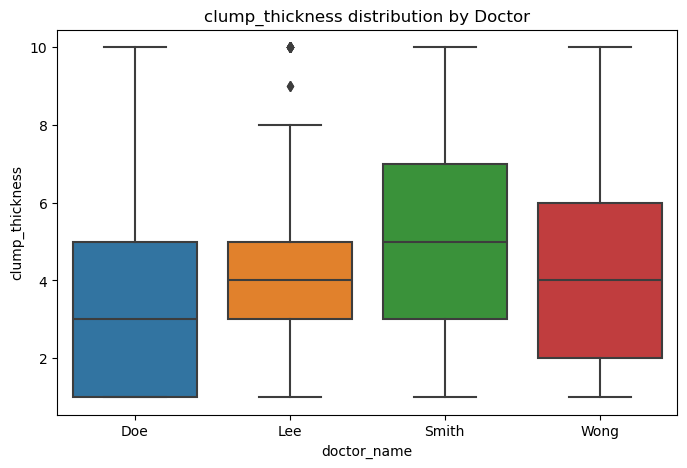

/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


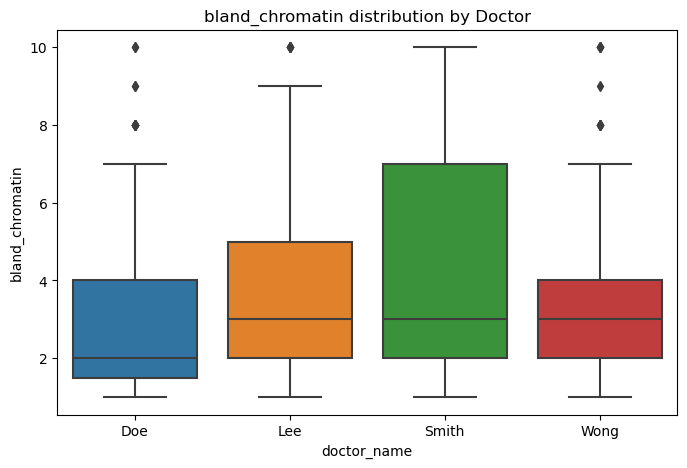

In [12]:
for feature in ['clump_thickness', 'bland_chromatin']:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='doctor_name', y=feature, data=bcd2)
    plt.title(f"{feature} distribution by Doctor")
    plt.show()

Tumor type distribution per doctor

In [14]:
display(bcd2.groupby('doctor_name')['class'].value_counts(normalize=True).unstack())

/var/folders/71/br_33dt53n948nsmj9czsvr80000gn/T/ipykernel_61316/3754176847.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(bcd2.groupby('doctor_name')['class'].value_counts(normalize=True).unstack())


class,benign,malignant
doctor_name,,
Doe,0.686486,0.313514
Lee,0.668508,0.331492
Smith,0.579545,0.420455
Wong,0.687898,0.312102


While Drs Doe, Lee, and Wong seem to have near identical values for most of these analyses, Dr. Smith tends to attribute higher clump thickness and bland chromatin to each tumor, leading to a much higher prevalence in malignant tumors in his reporting compared to the other three doctors.